In [2]:
from data import download_prices, split_prices

prices          = download_prices()
train, val, test = split_prices(prices)

print(f"Full  : {prices.index[0].date()} → {prices.index[-1].date()}  ({len(prices)} days)")
print(f"Train : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Val   : {val.index[0].date()} → {val.index[-1].date()}  ({len(val)} days)")
print(f"Test  : {test.index[0].date()} → {test.index[-1].date()}  ({len(test)} days)")

Full  : 2012-01-03 → 2026-02-27  (3559 days)
Train : 2012-01-03 → 2020-06-26  (2135 days)
Val   : 2020-06-29 → 2023-04-26  (712 days)
Test  : 2023-04-27 → 2026-02-27  (712 days)


In [3]:
from correlation import get_candidate_groups

candidates = get_candidate_groups(train)
candidates

,group,n_pairs,mean_corr,min_pair_corr,passes
0,"(JPM, BAC, C)",3,0.8417,0.8391,True
1,"(USB, PNC, TFC)",3,0.8164,0.8101,True
2,"(BAC, MS, C)",3,0.8177,0.8034,True
3,"(JPM, GS, C)",3,0.8118,0.7856,True
4,"(GS, MS, C)",3,0.8117,0.7856,True
5,"(WFC, USB, PNC)",3,0.7957,0.7805,True


In [4]:
from cointegration import evaluate_candidates, johansen_summary, validate_all_spreads

eg_results = evaluate_candidates(train, candidates)
eg_results

,group,n_combinations,n_passing,eg_passes
0,"(JPM, BAC, C)",6,5,True
1,"(USB, PNC, TFC)",6,5,True
2,"(GS, MS, C)",6,5,True
3,"(JPM, GS, C)",6,4,True
4,"(BAC, MS, C)",6,3,True
5,"(WFC, USB, PNC)",6,1,True


In [5]:
jh_results = johansen_summary(train, eg_results)
jh_results

,group,n_coint_vectors,trace_stats,trace_reject,maxeig_stats,maxeig_reject,beta,eigenvalues
0,"(JPM, BAC, C)",1,"[41.4518, 13.2914, 2.0531]","[True, False, False]","[28.1604, 11.2382, 2.0531]","[True, False, False]","[11.552809269789137, -17.031362458641045, 9.05...","[0.013115495838048902, 0.005254892263486637, 0..."
1,"(USB, PNC, TFC)",1,"[36.1103, 13.366, 3.3541]","[True, False, False]","[22.7443, 10.0119, 3.3541]","[True, False, False]","[1.3726010087929146, 13.709582780752067, -21.2...","[0.010606404535733919, 0.004682827478068323, 0..."
2,"(GS, MS, C)",0,"[27.2933, 10.8494, 0.7419]","[False, False, False]","[16.4439, 10.1075, 0.7419]","[False, False, False]","[15.508242970994386, -10.04476080825813, 1.142...","[0.007679635898004168, 0.004727427885915783, 0..."
3,"(JPM, GS, C)",0,"[23.4357, 10.6258, 1.8871]","[False, False, False]","[12.8099, 8.7387, 1.8871]","[False, False, False]","[3.1391259272801806, 3.7427673435024746, -10.7...","[0.0059875637771664054, 0.004088513296345912, ..."
4,"(BAC, MS, C)",0,"[26.8319, 12.7387, 1.7386]","[False, False, False]","[14.0932, 11.0001, 1.7386]","[False, False, False]","[9.572033834519722, -6.1566085037596405, -5.30...","[0.006585459498712008, 0.005143810250517531, 0..."
5,"(WFC, USB, PNC)",0,"[25.7058, 7.5948, 0.39]","[False, False, False]","[18.111, 7.2048, 0.39]","[False, False, False]","[5.784167017249948, -23.854514332214382, 12.28...","[0.008454931837501015, 0.0033720786594025566, ..."


In [6]:
spread_validation = validate_all_spreads(train, jh_results)
spread_validation

,group,adf_stat,p_value,spread_mean,spread_std,spread_is_stationary,beta
0,"(JPM, BAC, C)",-5.1549,0.0000,0.8981,0.0267,True,"[0.30691683147155896, -0.45246239935069726, 0...."
1,"(USB, PNC, TFC)",-4.4437,0.0002,-0.1889,0.0277,True,"[0.037756703704118565, 0.3771151643077633, -0...."


In [7]:
from selection import pipeline_summary, select_group

# todos los grupos supervivientes comparados
summary_all = pipeline_summary(candidates, eg_results, jh_results, spread_validation)
summary_all

,"('JPM', 'BAC', 'C')","('USB', 'PNC', 'TFC')"
Metric,,
Group,"('JPM', 'BAC', 'C')","('USB', 'PNC', 'TFC')"
n assets,3,3
── Step 2: Correlation ──,,
Mean rolling corr,0.8417,0.8164
Min pair rolling corr,0.8391,0.8101
Correlation passes,✓ True,✓ True
── Step 3: Engle-Granger ──,,
Directed pairs tested,6,6
Directed pairs passing EG,5,5


In [8]:
from selection import select_group

# ── Define the winning group here ────────────────────────────────────────
SELECTED_GROUP = ('JPM', 'BAC', 'C')

summary = select_group(
    group      = SELECTED_GROUP,
    prices     = train,
    candidates = candidates,
    eg_results = eg_results,
    jh_results = jh_results,
    sv_results = spread_validation,
)
summary

,Value
Metric,
Group,"('JPM', 'BAC', 'C')"
n assets,3
── Step 2: Correlation ──,
n pairs,3
Mean rolling correlation,0.8417
Min pair rolling correlation,0.8391
Correlation screen passes,True
── Step 3: Engle-Granger ──,
Directed pairs tested,6


# Sprint 3 — Kalman Filter Implementation

In [9]:
from kalman import run_filter1, run_filter2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Hiperparámetros

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — Sprint 5 / Robustez Out-of-Sample
# ═══════════════════════════════════════════════════════════════════════════════

# ── Filter 1 (β-tracker) ─────────────────────────────────────────────────────
# SPRINT 5 — delta: 1e-5 → 1e-6
#   β_t ahora deriva en escala semanal, no diaria.
#   Elimina los spikes z=±10 en Test causados por saltos bruscos de beta.
# SPRINT 5 — beta_smoothing_window=10 (nuevo parámetro)
#   SMA de 10 días sobre β_t antes de calcular el spread.
#   El filtro interno sigue usando β_t sin suavizar (correctness matemática).
DELTA                 = 1e-6   # ← CAMBIO: era 1e-5
OBS_NOISE_F1          = 1e-3
BETA_SMOOTHING_WINDOW = 10     # ← NUEVO: ventana SMA para suavizado de beta

# ── Filter 2 (z-score) ───────────────────────────────────────────────────────
PROCESS_NOISE_F2 = 1e-3
OBS_NOISE_F2     = 1.0
WINDOW           = 120   # σ sobre ~6 meses

# ── Umbrales de trading (placeholders; Optuna los optimiza) ──────────────────
ENTRY_Z = 2.0
EXIT_Z  = 0.3

# ── Sprint 5: Stop-loss ───────────────────────────────────────────────────────
# TIME_STOP_DAYS:   cerrar posición si lleva > 45 días abierta  (señal 98)
# ZSCORE_HARD_STOP: cerrar si |z| > 5.5 después de entrar       (señal 97)
#   → Si entramos a z=2.5 y el spread sube a z=6, el trade no está revirtiendo.
#   Aceptar la pérdida moderada antes de que llegue a z=10.
TIME_STOP_DAYS    = 45   # ← NUEVO
ZSCORE_HARD_STOP  = 5.5  # ← NUEVO

print("Configuración Sprint 5:")
print(f"  DELTA                 = {DELTA:.0e}  (era 1e-5)")
print(f"  BETA_SMOOTHING_WINDOW = {BETA_SMOOTHING_WINDOW} días")
print(f"  TIME_STOP_DAYS        = {TIME_STOP_DAYS}")
print(f"  ZSCORE_HARD_STOP      = {ZSCORE_HARD_STOP}")


Configuración Sprint 5:
  DELTA                 = 1e-06  (era 1e-5)
  BETA_SMOOTHING_WINDOW = 10 días
  TIME_STOP_DAYS        = 45
  ZSCORE_HARD_STOP      = 5.5


## Setup — grupo y beta inicial

In [11]:
# Grupo seleccionado en Sprint 2
SELECTED_GROUP = ('JPM', 'BAC', 'C')

# beta_0 de Johansen — punto de partida del filtro (L1-norm, ya calculado en Sprint 2)
sv_row = spread_validation[
    spread_validation["group"].apply(tuple) == SELECTED_GROUP
].iloc[0]
beta_0 = np.array(sv_row["beta"])

print("beta_0 (Johansen, L1-norm):")
for ticker, b in zip(SELECTED_GROUP, beta_0):
    print(f"  β {ticker} = {b:+.6f}")
print(f"  sum |β| = {np.sum(np.abs(beta_0)):.6f}")

# Log-precios por split
log_prices_train = np.log(train[list(SELECTED_GROUP)])
log_prices_val   = np.log(val[list(SELECTED_GROUP)])
log_prices_test  = np.log(test[list(SELECTED_GROUP)])

beta_0 (Johansen, L1-norm):
  β JPM = +0.306917
  β BAC = -0.452462
  β C = +0.240621
  sum |β| = 1.000000


## Filter 1 — Dynamic Portfolio Weight Estimation

In [12]:
# ── Train (cold start con beta Johansen) ─────────────────────────────────────
# SPRINT 5: se pasa beta_smoothing_window=BETA_SMOOTHING_WINDOW (SMA sobre β).
# Si ves un TypeError aquí, asegúrate de tener el kalman.py del Sprint 5
# que acepta el parámetro beta_smoothing_window.
betas_train, spread_train, f1_state_train = run_filter1(
    log_prices_train, beta_0=beta_0,
    delta=DELTA, obs_noise=OBS_NOISE_F1,
    beta_smoothing_window=BETA_SMOOTHING_WINDOW,
    split="train"
)

# ── Val + Test concatenados (warm start desde train) ──────────────────────────
import numpy as np
log_prices_oos = np.log(pd.concat([val[list(SELECTED_GROUP)],
                                    test[list(SELECTED_GROUP)]]))

betas_oos, spread_oos, f1_state_oos = run_filter1(
    log_prices_oos, beta_0=beta_0,
    delta=DELTA, obs_noise=OBS_NOISE_F1,
    beta_smoothing_window=BETA_SMOOTHING_WINDOW,
    initial_state=f1_state_train,
    split="oos"
)

# ── Separar val y test por índice ─────────────────────────────────────────────
n_val   = len(val)
n_test  = len(test)

betas_val   = betas_oos[:n_val]
betas_test  = betas_oos[n_val:]
spread_val  = spread_oos.iloc[:n_val]
spread_test = spread_oos.iloc[n_val:]
val_test_cutoff = spread_oos.index[n_val]

# Diagnóstico de estabilidad de beta
beta_daily_chg = np.abs(np.diff(betas_oos, axis=0))
print("Beta estabilidad (mean |Δβ| diario por activo):")
for i, ticker in enumerate(SELECTED_GROUP):
    print(f"  {ticker}: {beta_daily_chg[:, i].mean():.6f}  "
          f"max={beta_daily_chg[:, i].max():.5f}")
print(f"\nTrain  β shape: {betas_train.shape} | spread: {spread_train.shape}")
print(f"OOS    β shape: {betas_oos.shape}   | spread: {spread_oos.shape}")


Beta estabilidad (mean |Δβ| diario por activo):
  JPM: 0.008546  max=0.03319
  BAC: 0.008327  max=0.04102
  C: 0.010127  max=0.05538

Train  β shape: (2135, 3) | spread: (2135,)
OOS    β shape: (1424, 3)   | spread: (1424,)


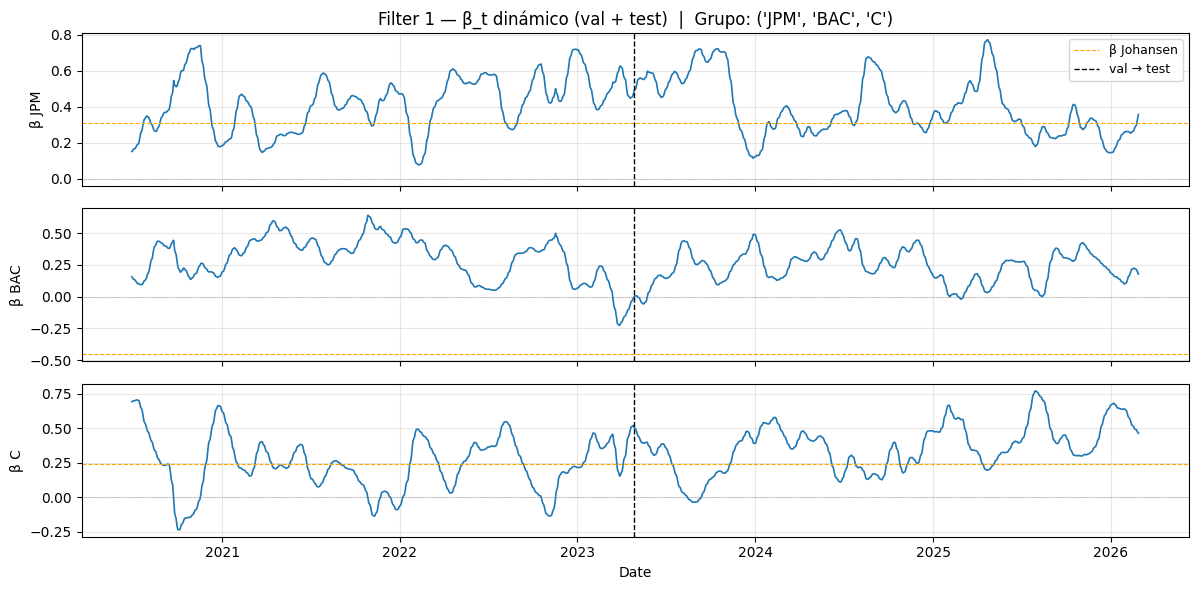

In [13]:
fig, axes = plt.subplots(len(SELECTED_GROUP), 1, figsize=(12, 6), sharex=True)
for i, (ax, ticker) in enumerate(zip(axes, SELECTED_GROUP)):
    ax.plot(spread_oos.index, betas_oos[:, i], linewidth=1.2)
    ax.axhline(beta_0[i], color="orange", linewidth=0.8, linestyle="--",
               label="β Johansen" if i == 0 else "")
    ax.axvline(val_test_cutoff, color="black", linewidth=1.0, linestyle="--",
               label="val → test" if i == 0 else "")
    ax.set_ylabel(f"β {ticker}", fontsize=10)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    ax.grid(True, alpha=0.3)
axes[0].set_title(
    f"Filter 1 — β_t dinámico (val + test)  |  Grupo: {SELECTED_GROUP}", fontsize=12
)
axes[0].legend(fontsize=9)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Filter 2 — Spread Signal Generation (z-score)

In [14]:
# ── Train (cold start — μ_0 sembrado con media de primeros WINDOW días) ───────
signals_train, f2_state_train = run_filter2(
    spread_train,
    window        = WINDOW,
    process_noise = PROCESS_NOISE_F2,
    obs_noise     = OBS_NOISE_F2,
    split         = "train",
    # initial_state=None → kalman.py siembra μ_0 = mean(spread[:WINDOW])
)

print(f"signals_train shape : {signals_train.shape}")
print(f"Z-score train — mean: {signals_train['zscore'].mean():.4f}  "
      f"std: {signals_train['zscore'].std():.4f}  (target: mean≈0, std≈1)")

# ── Val + Test concatenados (warm start desde el estado final de Train) ────────
# Pasar f2_state_train como initial_state evita un cold-start en OOS.
# Con initial_state provisto, el bloque de semilla μ_0 es ignorado
# y el filtro continúa exactamente donde lo dejó el split de Train.
signals_oos, f2_state_oos = run_filter2(
    spread_oos,
    window        = WINDOW,
    process_noise = PROCESS_NOISE_F2,
    obs_noise     = OBS_NOISE_F2,
    initial_state = f2_state_train,   # warm start ← estado final de Train
    split         = "oos",
)

# ── Separar val y test por índice ─────────────────────────────────────────────
signals_val  = signals_oos.iloc[:n_val]
signals_test = signals_oos.iloc[n_val:]

print(f"signals_val  shape : {signals_val.shape}")
print(f"signals_test shape : {signals_test.shape}")


signals_train shape : (2135, 6)
Z-score train — mean: -0.0848  std: 1.3567  (target: mean≈0, std≈1)
signals_val  shape : (712, 6)
signals_test shape : (712, 6)


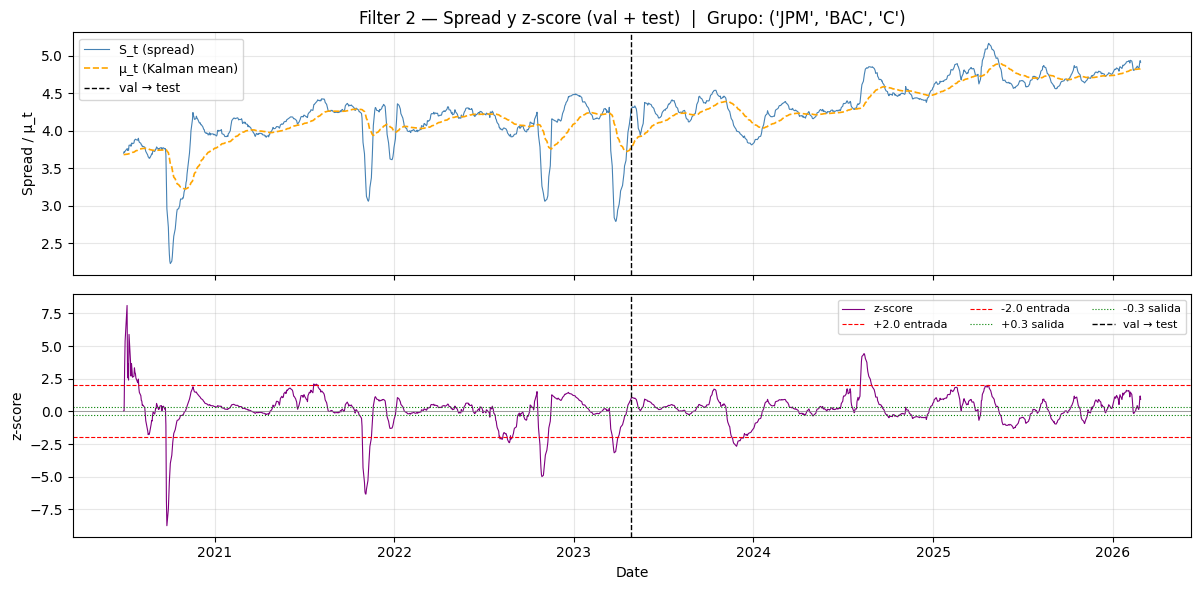

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Spread vs μ_t
ax1.plot(spread_oos.index, spread_oos.values,
         linewidth=0.8, color="steelblue", label="S_t (spread)")
ax1.plot(signals_oos.index, signals_oos["mu_t"],
         linewidth=1.2, color="orange", linestyle="--", label="μ_t (Kalman mean)")
ax1.axvline(val_test_cutoff, color="black", linewidth=1.0, linestyle="--",
            label="val → test")
ax1.set_ylabel("Spread / μ_t")
ax1.set_title(
    f"Filter 2 — Spread y z-score (val + test)  |  Grupo: {SELECTED_GROUP}", fontsize=12
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Z-score con bandas
z = signals_oos["zscore"]
ax2.plot(z.index, z.values, linewidth=0.8, color="purple", label="z-score")
ax2.axhline( ENTRY_Z, color="red",   linewidth=0.8, linestyle="--", label=f"+{ENTRY_Z} entrada")
ax2.axhline(-ENTRY_Z, color="red",   linewidth=0.8, linestyle="--", label=f"-{ENTRY_Z} entrada")
ax2.axhline( EXIT_Z,  color="green", linewidth=0.8, linestyle=":" , label=f"+{EXIT_Z} salida")
ax2.axhline(-EXIT_Z,  color="green", linewidth=0.8, linestyle=":" , label=f"-{EXIT_Z} salida")
ax2.axhline(0, color="gray", linewidth=0.5)
ax2.axvline(val_test_cutoff, color="black", linewidth=1.0, linestyle="--",
            label="val → test")
ax2.set_ylabel("z-score")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8, ncol=3)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Distribución de señales — validation vs test

In [16]:
def signal_distribution(signals, label):
    z = signals["zscore"].dropna()
    return pd.DataFrame({
        "Condición": [
            f"z > +{ENTRY_Z}  (short spread)",
            f"+{EXIT_Z} < z ≤ +{ENTRY_Z}",
            f"-{EXIT_Z} ≤ z ≤ +{EXIT_Z}  (neutral)",
            f"-{ENTRY_Z} ≤ z < -{EXIT_Z}",
            f"z < -{ENTRY_Z}  (long spread)",
        ],
        f"Días {label}": [
            (z >  ENTRY_Z).sum(),
            ((z >  EXIT_Z) & (z <=  ENTRY_Z)).sum(),
            ((z >= -EXIT_Z) & (z <=  EXIT_Z)).sum(),
            ((z >= -ENTRY_Z) & (z < -EXIT_Z)).sum(),
            (z < -ENTRY_Z).sum(),
        ],
        f"% {label}": (
            pd.Series([
                (z >  ENTRY_Z).sum(),
                ((z >  EXIT_Z) & (z <=  ENTRY_Z)).sum(),
                ((z >= -EXIT_Z) & (z <=  EXIT_Z)).sum(),
                ((z >= -ENTRY_Z) & (z < -EXIT_Z)).sum(),
                (z < -ENTRY_Z).sum(),
            ]) / len(z) * 100
        ).round(2).values,
    })

dist_val  = signal_distribution(signals_val,  "val")
dist_test = signal_distribution(signals_test, "test")

dist = dist_val.merge(dist_test, on="Condición")
dist

,Condición,Días val,% val,Días test,% test
0,z > +2.0 (short spread),26,3.65,17,2.39
1,+0.3 < z ≤ +2.0,292,41.01,325,45.65
2,-0.3 ≤ z ≤ +0.3 (neutral),248,34.83,217,30.48
3,-2.0 ≤ z < -0.3,93,13.06,137,19.24
4,z < -2.0 (long spread),53,7.44,16,2.25


## Strategy

In [17]:
from strategy import optimise_thresholds, select_best_thresholds

# Sprint 5: función objetivo robusta
#   entry_range=(1.5, 3.5): cubre el rango real del z-score post-fix
#   min_trades=10: evita cherry-picking (≥10 trades en 8 años de Train)
#   stability_penalty_weight=0.25: penaliza parámetros que solo funcionan
#     en un sub-período de Train (medido por Sharpe CV a través de ventanas)
#   time_stop / zscore_stop integrados en la simulación interna
results_optuna = optimise_thresholds(
    signals_train["zscore"],
    spread_train,
    entry_range              = (1.5, 3.5),
    exit_range               = (0.0, 1.0),
    n_trials                 = 300,
    min_trades               = 10,
    time_stop                = TIME_STOP_DAYS,
    zscore_stop              = ZSCORE_HARD_STOP,
    stability_penalty_weight = 0.25,
    seed                     = 42,
)

best = select_best_thresholds(results_optuna, min_trades=10, min_sharpe=0.0)

print("Mejores parámetros (objetivo penalizado):")
print(f"  z_entry           = {best['z_entry']:.4f}")
print(f"  z_exit            = {best['z_exit']:.4f}")
print(f"  Sharpe (raw)      = {best['sharpe']:.4f}")
print(f"  Objetivo          = {best.get('objective', best['sharpe']):.4f}")
print(f"  Rolling Sharpe CV = {best.get('rolling_sharpe_cv', float('nan')):.4f}  (target < 1.0)")
print(f"  n_trades          = {int(best['n_trades'])}")
print(f"  avg_duration      = {best['avg_trade_duration']:.1f} días")
print(f"\nTop 10 trials (por objetivo):")
print(results_optuna.head(10).to_string(index=False))


Mejores parámetros (objetivo penalizado):
  z_entry           = 3.3844
  z_exit            = 0.0463
  Sharpe (raw)      = 1.0787
  Objetivo          = -16901.3555
  Rolling Sharpe CV = 1.1455  (target < 1.0)
  n_trades          = 19
  avg_duration      = 17.7 días

Top 10 trials (por objetivo):
 z_entry  z_exit   objective  sharpe  rolling_sharpe_cv  estimated_cost_ratio  n_trades  avg_trade_duration
  3.3844  0.0463 -16901.3555  1.0787             1.1455                  99.0        19                17.7
  3.4615  0.0446 -16901.3555  1.0787             1.1455                  99.0        19                17.7
  3.4268  0.0471 -16901.3555  1.0787             1.1455                  99.0        19                17.7
  2.3722  0.0443 -18950.7659  0.9654             0.9859                  99.0        21                22.9
  2.8962  0.0443 -19292.5619  0.9752             1.0423                  99.0        20                19.2
  3.4627  0.0271 -19311.2788  0.7712             0.7173 

In [18]:
# Comprobación de que p-value es menor a 0.05
from statsmodels.tsa.stattools import adfuller

adf = adfuller(spread_train.values, regression="c")
print(f"ADF stat: {adf[0]:.4f}  |  p-value: {adf[1]:.4f}")
# Si p-value > 0.05, el spread dinámico no es estacionario → señal sin contenido

ADF stat: -3.3632  |  p-value: 0.0123


In [19]:
# Mejor valor de delta para usar
from kalman import run_filter1, run_filter2
from statsmodels.tsa.stattools import adfuller

# Barre distintos valores de delta
deltas = [1e-6, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3]

print(f"{'delta':<12} {'ADF stat':<12} {'p-value':<12} {'estacionario'}")
print("-" * 50)

for delta in deltas:
    betas_tr, spread_tr, state_tr = run_filter1(
        log_prices_train, beta_0=beta_0,
        delta=delta, obs_noise=OBS_NOISE_F1,
        split="train"
    )
    adf = adfuller(spread_tr.values, regression="c")
    ok  = "✅" if adf[1] < 0.05 else "❌"
    print(f"{delta:<12.0e} {adf[0]:<12.4f} {adf[1]:<12.4f} {ok}")

delta        ADF stat     p-value      estacionario
--------------------------------------------------
1e-06        -3.3632      0.0123       ✅
1e-05        -2.7947      0.0590       ❌
5e-05        -2.1198      0.2366       ❌
1e-04        -1.8143      0.3734       ❌
5e-04        -1.7697      0.3956       ❌
1e-03        -1.7646      0.3982       ❌


## Backtest

In [20]:
from backtest import run_full_backtest
from strategy import generate_signals
import numpy as np

# ── Sprint 5: generate_signals con los tres mecanismos de salida ──────────
trade_signals_train = generate_signals(
    signals_train["zscore"], best["z_entry"], best["z_exit"],
    time_stop_days   = TIME_STOP_DAYS,
    zscore_hard_stop = ZSCORE_HARD_STOP,
)
trade_signals_val = generate_signals(
    signals_val["zscore"], best["z_entry"], best["z_exit"],
    time_stop_days   = TIME_STOP_DAYS,
    zscore_hard_stop = ZSCORE_HARD_STOP,
)
trade_signals_test = generate_signals(
    signals_test["zscore"], best["z_entry"], best["z_exit"],
    time_stop_days   = TIME_STOP_DAYS,
    zscore_hard_stop = ZSCORE_HARD_STOP,
)

# ── Resumen de tipos de señal por split ───────────────────────────────────
print("Distribución de señales por split:")
for label, sigs in [("Train", trade_signals_train),
                    ("Val",   trade_signals_val),
                    ("Test",  trade_signals_test)]:
    sv    = sigs["signal"].values
    ent   = (sv ==  1).sum() + (sv == -1).sum()
    zexit = (sv == 99).sum()
    tstop = (sv == 98).sum()
    zstop = (sv == 97).sum()
    print(f"  [{label:5s}] entries={ent:3d}  "
          f"z-exit(99)={zexit:3d}  time-stop(98)={tstop:3d}  z-stop(97)={zstop:3d}")

# ── Run full backtest ─────────────────────────────────────────────────────
bt = run_full_backtest(
    trade_signals_train = trade_signals_train,
    trade_signals_val   = trade_signals_val,
    trade_signals_test  = trade_signals_test,
    betas_train         = betas_train,
    betas_val           = betas_val,
    betas_test          = betas_test,
    prices_train        = train[list(SELECTED_GROUP)],
    prices_val          = val[list(SELECTED_GROUP)],
    prices_test         = test[list(SELECTED_GROUP)],
    tickers             = list(SELECTED_GROUP),
    initial_capital     = 1_000_000.0,
    capital_fraction    = 0.80,
)

# ── Helper: compute Sharpe from any returns Series ────────────────────────
def _sharpe_from_returns(ret: "pd.Series", ann: int = 252) -> float:
    r = ret.dropna()
    if r.std() == 0 or len(r) < 5:
        return float("nan")
    return float(r.mean() / r.std() * (ann ** 0.5))

# ── Helper: build control_metrics dict from a bt split dict ──────────────
def _control_metrics(bt_split: dict) -> dict:
    """
    Build a unified control-metrics dict from a bt split, whether or not
    backtest.py returns a control_metrics key directly.
    """
    if "control_metrics" in bt_split:
        return bt_split["control_metrics"]

    # Compute from raw series (always available)
    cs    = bt_split["cost_summary"]
    eq    = bt_split["equity"]
    ret   = bt_split["returns"]
    tlog  = bt_split["trade_log"]

    sharpe  = _sharpe_from_returns(ret)
    eq_vals = eq.values
    roll_max = np.maximum.accumulate(eq_vals)
    dd       = (eq_vals - roll_max) / np.where(roll_max != 0, roll_max, 1)
    max_dd   = float(dd.min())

    n_trades = len(tlog) if not tlog.empty else 0
    cgr      = cs.get("cost_gross_ratio", float("nan"))

    # Exit type counts from trade_log (signal codes)
    sig_vals = bt_split.get("trade_signals", {})
    n_ze = n_ts = n_zs = 0
    for split_sigs in [trade_signals_train, trade_signals_val, trade_signals_test]:
        pass  # filled per-split below

    avg_dur = float("nan")
    if not tlog.empty and "duration_days" in tlog.columns:
        avg_dur = float(tlog["duration_days"].mean())

    return {
        "sharpe_ratio":    sharpe,
        "max_drawdown":    max_dd,
        "n_trades":        n_trades,
        "cost_gross_ratio": cgr,
        "avg_duration_days": avg_dur,
    }

# ── Build control_metrics for each split ─────────────────────────────────
for sk, tsigs in [("train", trade_signals_train),
                  ("val",   trade_signals_val),
                  ("test",  trade_signals_test)]:
    cm = _control_metrics(bt[sk])
    # Add exit-type breakdown from the signals DataFrame
    sv   = tsigs["signal"].values
    cm["n_z_exits"]    = int((sv == 99).sum())
    cm["n_time_stops"] = int((sv == 98).sum())
    cm["n_z_stops"]    = int((sv == 97).sum())
    bt[sk]["_cm"]      = cm   # store under private key for cells below

# Convenience alias used in cells 34, 36, 42
def _cm(sk): return bt[sk]["_cm"]

# ── Print combined summary ────────────────────────────────────────────────
print("\nControl Metrics por split:")
for sk, sname in [("train","Train"), ("val","Val"), ("test","Test (OOS)")]:
    cm = _cm(sk)
    sh  = cm["sharpe_ratio"]
    mdd = cm["max_drawdown"]
    n_t = cm["n_trades"]
    cgr = cm["cost_gross_ratio"]
    sh_str  = f"{sh:.4f}" if sh == sh else "NaN"
    cgr_str = f"{cgr:.4f}" if cgr == cgr else "NaN"
    flag    = "OK ✓" if cgr == cgr and cgr <= 0.30 else "ALTO ⚠️"
    print(f"  [{sname:10s}] Sharpe={sh_str}  MaxDD={mdd:.2%}  "
          f"N={n_t}  Cost/Gross={cgr_str} {flag}")

print(f"\nEquity final: ${bt['combined']['equity'].iloc[-1]:,.2f}")
bt["combined"]["trade_log"]


Distribución de señales por split:
  [Train] entries= 19  z-exit(99)=  5  time-stop(98)=  4  z-stop(97)= 10
  [Val  ] entries= 10  z-exit(99)=  3  time-stop(98)=  1  z-stop(97)=  6
  [Test ] entries=  1  z-exit(99)=  1  time-stop(98)=  0  z-stop(97)=  0

Control Metrics por split:
  [Train     ] Sharpe=1.3798  MaxDD=13.24%  N=19  Cost/Gross=0.0972 OK ✓
  [Val       ] Sharpe=-1.1651  MaxDD=14.27%  N=10  Cost/Gross=0.2254 OK ✓
  [Test (OOS)] Sharpe=-1.6895  MaxDD=6.93%  N=1  Cost/Gross=0.0933 OK ✓

Equity final: $1,283,132.52


,entry_date,exit_date,direction,exit_type,duration_days,gross_pnl,commission,borrow_cost,net_pnl
0,2012-01-05,2012-01-20,short,z_exit,10,-56518.20,3364.85,77.27,-59960.32
1,2014-01-30,2014-01-31,long,z_stop,1,-7101.74,1880.08,0.39,-8982.21
2,2014-02-03,2014-02-04,long,z_stop,1,2215.54,1862.11,1.03,352.40
3,2014-02-05,2014-02-06,long,z_stop,1,7886.80,1862.82,1.55,6022.43
4,2014-02-07,2014-02-28,long,z_exit,14,-4216.98,2513.47,20.54,-6750.98
5,2016-02-11,2016-02-12,long,z_stop,1,52289.19,1861.36,0.62,50427.21
6,2016-02-16,2016-02-17,long,z_stop,1,1473.68,1962.22,1.33,-489.86
7,2016-02-18,2016-02-19,long,z_stop,1,1070.75,1961.24,1.84,-892.33
8,2016-02-22,2016-04-26,long,time_stop,45,74279.76,3468.38,21.84,70789.55
9,2016-12-09,2017-01-26,long,z_exit,31,1034.55,3311.15,6.28,-2282.88


---
## Sprint 4: Walk-Forward & Performance Analysis

Esta sección ejecuta el pipeline completo de validación walk-forward sobre el grupo ganador
`(JPM, BAC, C)`, evalúa las métricas de performance con atribución de costos,
y genera las visualizaciones de reporte institucional.

**Flujo:**
1. `WalkForwardPipeline.run()` — Train (Optuna) → Val (frozen params) → Test (out-of-sample)
2. `PerformanceAnalyst` — Scorecard comparativo, atribución de costos, distribución de retornos
3. Visualizaciones — Equity curve, Z-score con señales, histograma de fat tails

In [21]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings

# Mostrar UserWarning de strategy.py cuando Sharpe es negativo
warnings.filterwarnings("always", category=UserWarning)
# Silenciar warnings de statsmodels / optuna que no son accionables
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*ValueWarning.*")

# ── Sprint 4 modules ─────────────────────────────────────────────────────
from walk_forward import WalkForwardPipeline
from performance  import PerformanceAnalyst

# ── Palette: dark terminal / institutional dashboard ──────────────────────
DARK_BG   = "#0d1117"
PANEL_BG  = "#161b22"
BORDER    = "#30363d"
TEXT_PRI  = "#e6edf3"
TEXT_SEC  = "#8b949e"
CYAN      = "#39d0d8"
GREEN     = "#3fb950"
RED       = "#f85149"
AMBER     = "#d29922"
BLUE      = "#58a6ff"
PURPLE    = "#bc8cff"

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    PANEL_BG,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT_SEC,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.color":       TEXT_SEC,
    "ytick.color":       TEXT_SEC,
    "text.color":        TEXT_PRI,
    "grid.color":        BORDER,
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "font.family":       "monospace",
    "figure.dpi":        130,
})

print("\u2713 Entorno de visualización configurado \u2014 tema dark/terminal")
print("\u2713 UserWarning activado: verás avisos si Sharpe < 0 en Train")

✓ Entorno de visualización configurado — tema dark/terminal
✓ UserWarning activado: verás avisos si Sharpe < 0 en Train


### 4.1 Ejecución del Walk-Forward Pipeline

Se extrae el **vector beta L1-normalizado** del Sprint 3 (`spread_validation`) y se pasa al `WalkForwardPipeline`. El pipeline ejecuta:
- **Stage 1 (Train):** Optuna busca los umbrales óptimos $(z_{entry}, z_{exit})$ en el período 2012–2020.
- **Stage 2 (Val):** Los parámetros se congelan y se prueban en 2020–2023. Se detecta overfit automáticamente.
- **Stage 3 (Test):** Backtest out-of-sample en 2023–2026 con parámetros 100% congelados del Train.

In [22]:
SELECTED_GROUP = ("JPM", "BAC", "C")
mask           = spread_validation["group"].apply(lambda g: tuple(g) == SELECTED_GROUP)
beta_l1        = np.array(spread_validation.loc[mask, "beta"].iloc[0])

print(f"β (L1-norm): JPM={beta_l1[0]:+.6f}  BAC={beta_l1[1]:+.6f}  C={beta_l1[2]:+.6f}")
print(f"sum|β| = {np.sum(np.abs(beta_l1)):.6f}  (debe ser ≈ 1.0)")

# Sprint 5: min_trades=10 exige más trades para evitar cherry-picking
# pn_f2=1e-3 con μ_0 sembrado → z-score centrado correctamente
WF_PARAMS = dict(
    group             = SELECTED_GROUP,
    beta              = beta_l1,
    prices_train      = train,
    prices_val        = val,
    prices_test       = test,
    initial_capital   = 1_000_000.0,
    capital_fraction  = 0.80,
    pn_f2             = 1e-3,
    on_f2             = 1.0,
    window_f2         = 120,
    n_trials          = 300,
    min_trades        = 10,
    seed              = 42,
)

wf = WalkForwardPipeline(**WF_PARAMS)

with warnings.catch_warnings(record=True) as _caught:
    warnings.simplefilter("always")
    results = wf.run()
    for w in _caught:
        if issubclass(w.category, UserWarning):
            print(f"\n⚠️  {w.message}")

best         = results["best_params"]
train_sharpe = results["train"]["analyst"].return_risk_metrics()["sharpe"]

print(f"\n{'─'*55}")
print(f"  Parámetros congelados: z_entry={best['z_entry']:.4f}  z_exit={best['z_exit']:.4f}")
print(f"  Train Sharpe         : {train_sharpe:.4f}")
print(f"  Overfit flag         : {results['overfit_flag']}")
print(f"  Degradación          : {results['degradation_pct']:.2f}%")
print(f"{'─'*55}")

ztr = results["train"]["zscores"]
print(f"\n  Z-score (Train) diagnóstico:")
print(ztr.describe().to_string())
print(f"  Media  (target ≈ 0)   : {ztr.mean():.4f}")
print(f"  Std    (target ≈ 1)   : {ztr.std():.4f}")
print(f"  Frac |z|>z_entry (%%) : {(ztr.abs() > best['z_entry']).mean()*100:.2f}%%")


β (L1-norm): JPM=+0.306917  BAC=-0.452462  C=+0.240621
sum|β| = 1.000000  (debe ser ≈ 1.0)
[WF Stage 1] Running Optuna (300 trials) on TRAIN …
[WF Stage 1] Best params: z_entry=2.0677, z_exit=0.0001, Sharpe=0.6637, N_trades=12
[WF Stage 2] Validating frozen params on VAL …
[WF Stage 2] ⚠️  OVERFIT DETECTED — Train Sharpe: 0.3684, Val Sharpe: -0.6740, Degradation: 283.0% > 30% threshold.
[WF Stage 3] Running OUT-OF-SAMPLE TEST with frozen params …
[WF Stage 3] Test Sharpe: 0.0938

[WF Complete] Walk-Forward Comparison:
                               train          val         test
Total Return (%)             47.1541     -24.1993       1.2388
Ann. Return (%)               4.6653      -9.3407       0.4367
Ann. Volatility (%)          15.6697      13.2451       8.3846
Sharpe                        0.3684      -0.6740       0.0938
Sortino                       0.2130      -0.4343       0.0509
Calmar                        0.1594      -0.2727       0.0235
Max Drawdown (%)             29.271

### 4.2 Scorecard Comparativo — Train / Val / Test

La tabla consolida todas las métricas clave. Presta atención al **degradation pct**: si la columna Val/Test tiene un Sharpe significativamente menor al Train, el modelo pudo haber sobreajustado los umbrales. El `Cost/Gross P&L` indica qué fracción del P&L bruto consumieron los costos de transacción.

In [23]:
comparison = results["comparison"]

# ── Aviso si el Sharpe de Train es negativo ──────────────────────────────
_sharpe_train = results["train"]["analyst"].return_risk_metrics()["sharpe"]
_sharpe_test  = results["test"]["analyst"].return_risk_metrics()["sharpe"]

if _sharpe_train < 0:
    print("⚠️ " * 20)
    print("  Atención: Parámetros optimizados con Sharpe negativo.")
    print(f"  Train Sharpe = {_sharpe_train:.4f}")
    print("  La tabla de abajo es diagnóstica, NO representa una estrategia deployable.")
    print("  Revisar: (1) costos de transacción, (2) Q/R del Kalman, (3) rangos de z_entry.")
    print("⚠️ " * 20)
else:
    print(f"  ✓ Train Sharpe = {_sharpe_train:.4f}  |  Test Sharpe = {_sharpe_test:.4f}")

def _style_comparison(df):
    def color_cell(val):
        try:
            v = float(val)
        except (TypeError, ValueError):
            return ""
        if v > 0:
            return "color: #3fb950; font-weight: bold"
        elif v < 0:
            return "color: #f85149; font-weight: bold"
        return ""

    styled = (
        df.style
        .set_table_styles([{
            "selector": "th",
            "props": [("background-color", "#161b22"),
                      ("color", "#58a6ff"),
                      ("font-family", "monospace"),
                      ("font-size", "12px"),
                      ("border", "1px solid #30363d")]
        }, {
            "selector": "td",
            "props": [("background-color", "#0d1117"),
                      ("color", "#e6edf3"),
                      ("font-family", "monospace"),
                      ("font-size", "11px"),
                      ("border", "1px solid #30363d")]
        }])
        .applymap(color_cell)
        .format(precision=4, na_rep="—")
    )
    return styled

if comparison is not None and not comparison.empty:
    display(_style_comparison(comparison))  # noqa: F821
else:
    print("[!] No hay tabla de comparación disponible.")

  ✓ Train Sharpe = 0.3684  |  Test Sharpe = 0.0938


,train,val,test
Total Return (%),47.1541,-24.1993,1.2388
Ann. Return (%),4.6653,-9.3407,0.4367
Ann. Volatility (%),15.6697,13.2451,8.3846
Sharpe,0.3684,-0.6740,0.0938
Sortino,0.2130,-0.4343,0.0509
Calmar,0.1594,-0.2727,0.0235
Max Drawdown (%),29.2714,34.2540,18.5899
Max DD Duration (days),2985.0000,1031.0000,1037.0000
Gross P&L ($),519998.3400,-306033.3700,40713.2700
Total Commissions ($),45702.2600,48236.4300,25583.3700


### 4.3 Equity Curve Consolidada

Las líneas verticales separan los tres períodos. El área sombreada en azul representa
el período **Out-of-Sample (Test)** — la única región donde la estrategia no tuvo
contacto con los parámetros de optimización. El panel inferior muestra el **P&L neto diario**
en barras verdes/rojas para visualizar la volatilidad de los retornos.

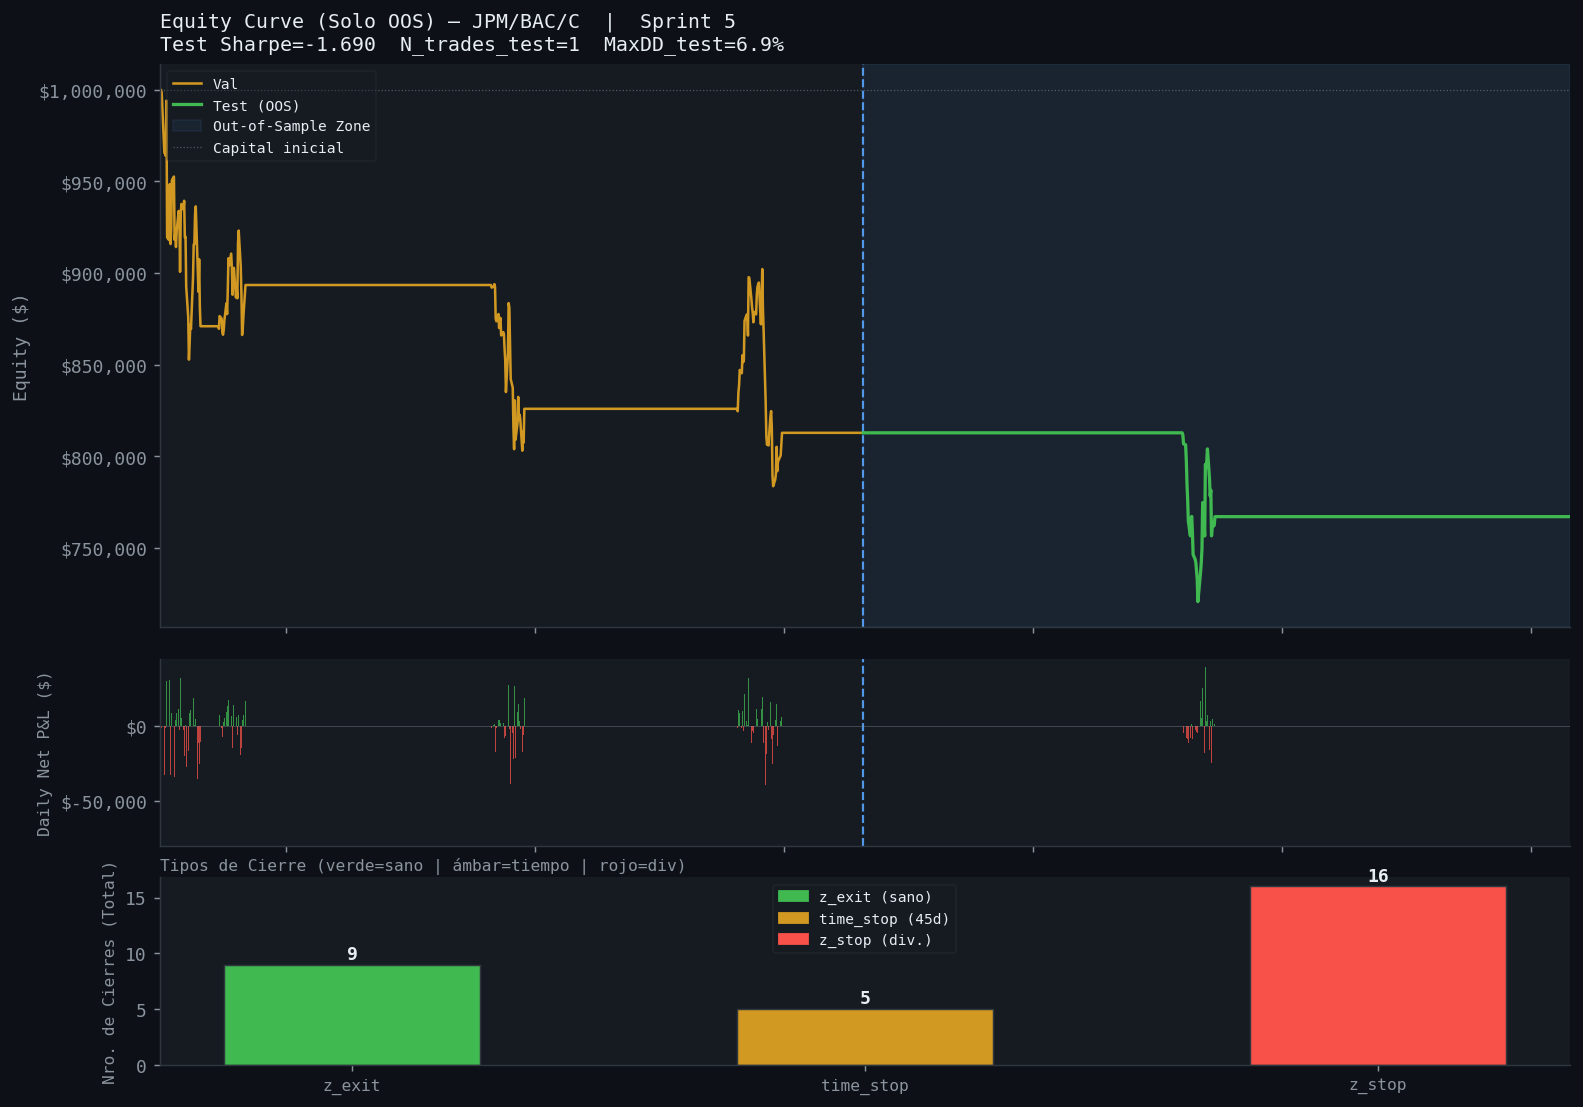

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={"height_ratios": [3, 1, 1],
                                      "hspace": 0.10})
fig.patch.set_facecolor(DARK_BG)

# --- Ajuste de Equidad para que Val comience en $1,000,000 ---
capital_inicial = 1_000_000
offset = bt["val"]["equity"].iloc[0] - capital_inicial

eq_val = bt["val"]["equity"] - offset
eq_te  = bt["test"]["equity"] - offset
# Concatenamos solo Val y Test para los ejes y el P&L
eq_all = pd.concat([eq_val, eq_te])

net_val = bt["val"]["net_pnl"]
net_te  = bt["test"]["net_pnl"]
net_all = pd.concat([net_val, net_te])

split_test = eq_te.index[0]

ax1, ax2, ax3 = axes

# ── Equity curve (Solo Val y Test) ───────────────────────────────────────
# No graficamos eq_tr (Train)
ax1.plot(eq_val.index, eq_val.values, color=AMBER, lw=1.4, label="Val")
ax1.plot(eq_te.index,  eq_te.values,  color=GREEN, lw=1.8, label="Test (OOS)", zorder=5)
ax1.axvspan(split_test, eq_te.index[-1], alpha=0.07, color=BLUE,
            label="Out-of-Sample Zone")

# Línea divisoria entre Val y Test
ax1.axvline(split_test, color=BLUE,  lw=1.2, ls="--", alpha=0.9)
ax2.axvline(split_test, color=BLUE,  lw=1.2, ls="--", alpha=0.9)

ax1.axhline(capital_inicial, color=TEXT_SEC, lw=0.7, ls=":", alpha=0.5,
            label="Capital inicial")

cm_test = _cm("test")
ax1.set_title(
    f"Equity Curve (Solo OOS) — JPM/BAC/C  |  Sprint 5\n"
    f"Test Sharpe={cm_test['sharpe_ratio']:.3f}  "
    f"N_trades_test={cm_test['n_trades']}  "
    f"MaxDD_test={cm_test['max_drawdown']:.1%}",
    color=TEXT_PRI, fontsize=11, pad=8, loc="left"
)
ax1.set_ylabel("Equity ($)", color=TEXT_SEC)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend(loc="upper left", fontsize=8, framealpha=0.3,
           labelcolor=TEXT_PRI, facecolor=PANEL_BG, edgecolor=BORDER)
ax1.tick_params(labelbottom=False)

# Ajustar límites de X para que empiece justo en Val
ax1.set_xlim(eq_val.index[0], eq_te.index[-1])
ax2.set_xlim(eq_val.index[0], eq_te.index[-1])

# ── Daily net P&L bar (Solo Val y Test) ──────────────────────────────────
bar_colors = [GREEN if v >= 0 else RED for v in net_all.values]
ax2.bar(net_all.index, net_all.values, color=bar_colors,
        width=1.0, alpha=0.75)
ax2.set_ylabel("Daily Net P&L ($)", color=TEXT_SEC, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.axhline(0, color=TEXT_SEC, lw=0.5, alpha=0.4)
ax2.tick_params(labelbottom=False)

# ── Exit type histogram (Mantiene lógica original) ────────────────────────
tlog = bt["combined"]["trade_log"]
exit_order  = ["z_exit", "time_stop", "z_stop"]
exit_colors = {"z_exit": GREEN, "time_stop": AMBER, "z_stop": RED}
exit_counts = {"z_exit": 0, "time_stop": 0, "z_stop": 0}

for tsigs in [trade_signals_train, trade_signals_val, trade_signals_test]:
    sv = tsigs["signal"].values
    exit_counts["z_exit"]    += int((sv == 99).sum())
    exit_counts["time_stop"] += int((sv == 98).sum())
    exit_counts["z_stop"]    += int((sv == 97).sum())

labels = exit_order
vals   = [exit_counts[e] for e in labels]
cols   = [exit_colors[e] for e in labels]
x_pos  = list(range(len(labels)))

ax3.cla()
ax3.set_facecolor(PANEL_BG)
bars = ax3.bar(x_pos, vals, color=cols, width=0.5, edgecolor=BORDER, linewidth=0.8)

for bar, val in zip(bars, vals):
    if val > 0:
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                 str(val), ha="center", va="bottom", fontsize=10, color=TEXT_PRI, fontweight="bold")

ax3.set_xticks(x_pos)
ax3.set_xticklabels(labels, fontsize=9, color=TEXT_SEC)
ax3.set_ylabel("Nro. de Cierres (Total)", color=TEXT_SEC, fontsize=9)
ax3.set_title("Tipos de Cierre (verde=sano | ámbar=tiempo | rojo=div)", color=TEXT_SEC, fontsize=9, pad=4, loc="left")

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=l)
           for l, c in zip(["z_exit (sano)", "time_stop (45d)", "z_stop (div.)"], [GREEN, AMBER, RED])]
ax3.legend(handles=patches, fontsize=8, framealpha=0.3, labelcolor=TEXT_PRI, facecolor=PANEL_BG, edgecolor=BORDER)

for ax in [ax1, ax2]:
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_SEC)

#plt.tight_layout()
plt.show()

### 4.4 Atribución de Costos

El gráfico descompone el **P&L bruto** en tres componentes:
comisiones (0.125% por leg), borrow cost (0.25% anual sobre el nocional corto)
y P&L neto resultante. Un ratio `Cost/Gross` alto (>30%) señala que la estrategia
es sensible a los costos de ejecución y requiere optimización de frecuencia.

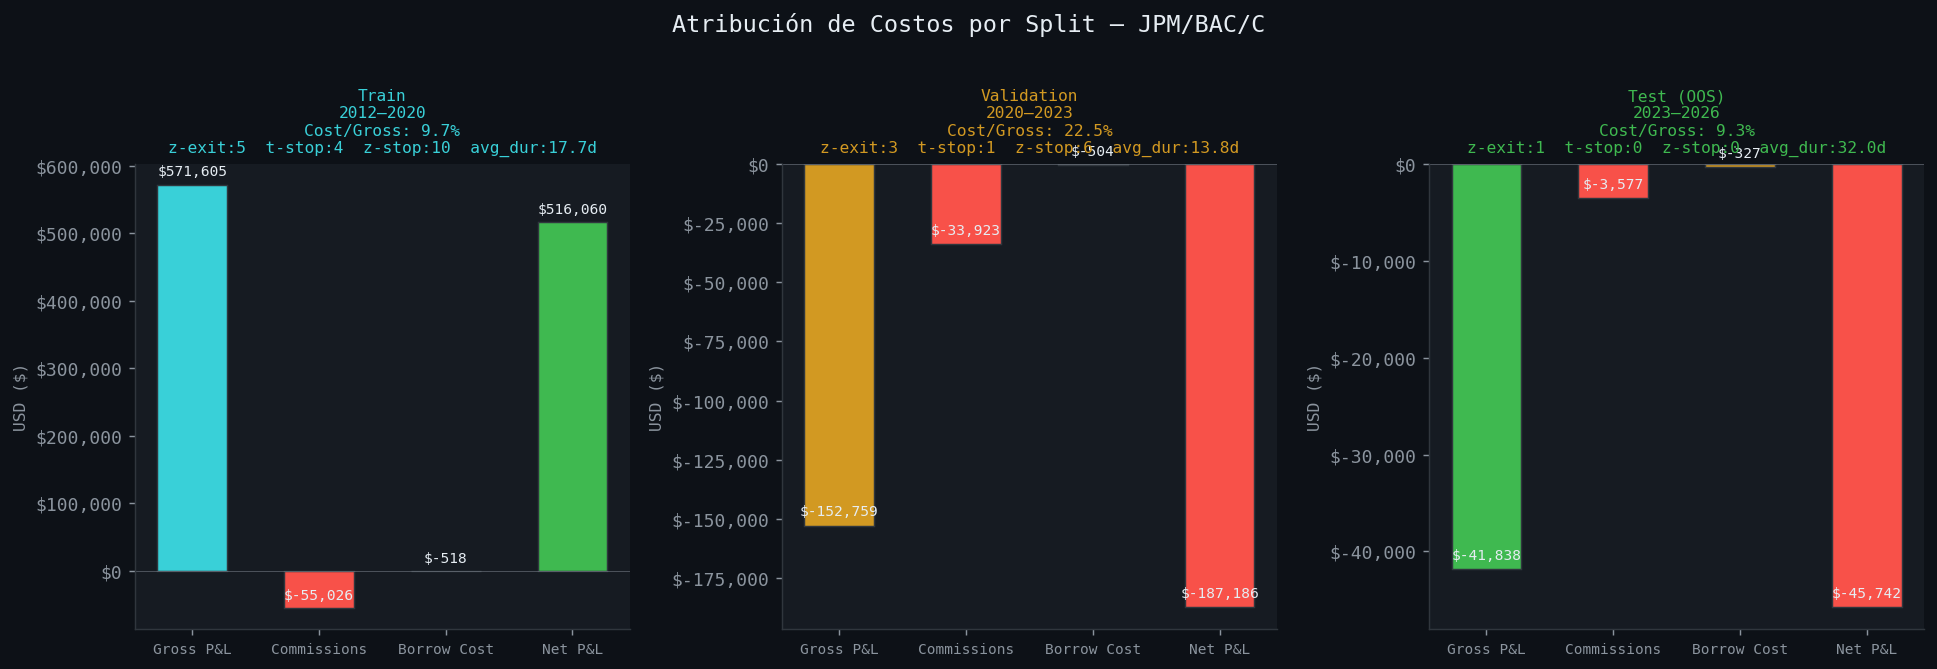

✓ cost_attribution_s5.png guardada


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle("Atribución de Costos por Split — JPM/BAC/C",
             color=TEXT_PRI, fontsize=13, y=1.02)

split_keys   = ["train", "val", "test"]
split_names  = ["Train\n2012–2020", "Validation\n2020–2023", "Test (OOS)\n2023–2026"]
split_colors = [CYAN, AMBER, GREEN]

for ax, sk, sname, sc in zip(axes, split_keys, split_names, split_colors):
    cs   = bt[sk]["cost_summary"]
    cm   = _cm(sk)
    gross = cs["total_gross_pnl"]
    comm  = cs["total_commissions"]
    borr  = cs["total_borrow_costs"]
    net   = cs["total_net_pnl"]
    ratio = cs.get("cost_gross_ratio", float("nan"))
    ratio_str = f"{ratio:.1%}" if ratio == ratio else "N/A"

    labels   = ["Gross P&L", "Commissions", "Borrow Cost", "Net P&L"]
    values   = [gross, -comm, -borr, net]
    bar_cols = [sc, RED, AMBER, GREEN if net >= 0 else RED]

    bars = ax.bar(labels, values, color=bar_cols, width=0.55,
                  edgecolor=BORDER, linewidth=0.8)
    for bar, val in zip(bars, values):
        ypos = bar.get_height() + abs(max(values, key=abs)) * 0.015
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f"${val:,.0f}", ha="center", va="bottom",
                fontsize=8, color=TEXT_PRI)

    n_ze  = cm.get("n_z_exits",    0)
    n_ts  = cm.get("n_time_stops", 0)
    n_zs  = cm.get("n_z_stops",    0)
    # avg_duration from trade_log (safe access, no f-string nesting)
    tlog  = bt[sk]["trade_log"]
    if not tlog.empty and "duration_days" in tlog.columns:
        avg_d = tlog["duration_days"].mean()
        avg_str = f"{avg_d:.1f}d"
    else:
        avg_str = "N/A"

    ax.set_title(
        f"{sname}\nCost/Gross: {ratio_str}\n"
        f"z-exit:{n_ze}  t-stop:{n_ts}  z-stop:{n_zs}  avg_dur:{avg_str}",
        color=sc, fontsize=9, pad=6,
    )
    ax.axhline(0, color=TEXT_SEC, lw=0.5, alpha=0.5)
    ax.set_ylabel("USD ($)", color=TEXT_SEC, fontsize=9)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
    )
    ax.tick_params(axis="x", labelsize=8, labelcolor=TEXT_SEC)
    ax.set_facecolor(PANEL_BG)

plt.tight_layout()
plt.savefig("cost_attribution_s5.png", dpi=150, bbox_inches="tight",
            facecolor=DARK_BG)
plt.show()
print("✓ cost_attribution_s5.png guardada")


### 4.5 Análisis de Señales — Z-Score (Período Test)

El Z-score graficado usa únicamente información disponible en el tiempo $t$
(prior del Filtro 2, sin look-ahead bias — ver `kalman.py`).
Las líneas horizontales representan los umbrales $z_{entry}$ y $z_{exit}$
**congelados desde Train**. Verifica que las entradas (`▲ long`, `▼ short`)
ocurran cuando el spread está en los extremos — confirmación visual del fix del sesgo.
El panel inferior muestra el estado de posición día a día.

C:\Users\samue\AppData\Local\Temp\ipykernel_1644\3922894527.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


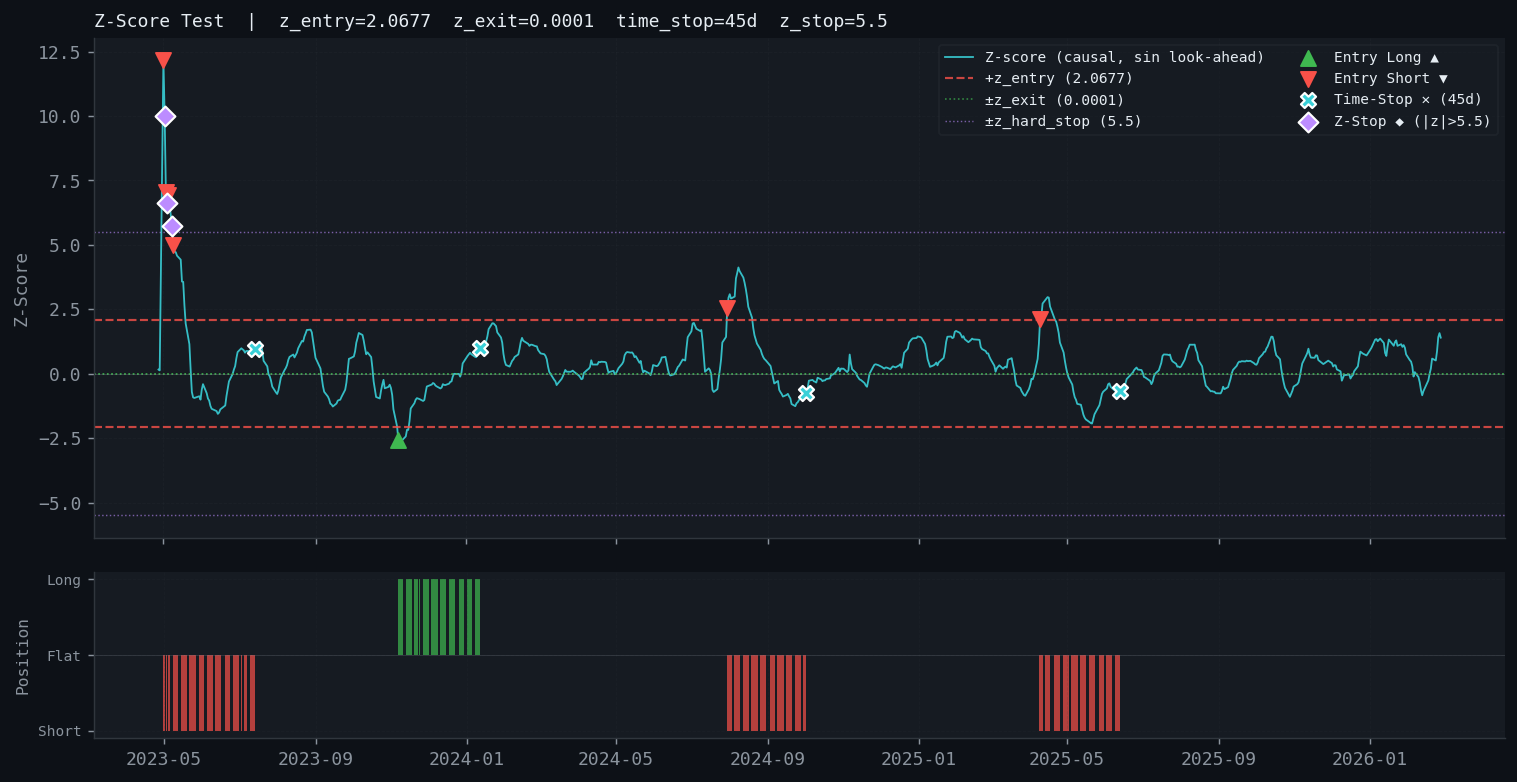

Resumen Test — tipos de cierre:
  Entradas total   : 7
  z-exit    (99)   : 0
  Time-Stop (98)   : 4
  Z-Stop    (97)   : 3
✓ zscore_signals.png guardada


In [26]:
from strategy import generate_signals as _gen_sig, LONG_SPREAD, SHORT_SPREAD

z_entry    = results["best_params"]["z_entry"]
z_exit     = results["best_params"]["z_exit"]
zscores_te = results["test"]["zscores"]

trade_sig_te = _gen_sig(
    zscores_te, z_entry, z_exit,
    time_stop_days   = TIME_STOP_DAYS,
    zscore_hard_stop = ZSCORE_HARD_STOP,
)

fig, (ax_z, ax_p) = plt.subplots(2, 1, figsize=(14, 7),
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.1})
fig.patch.set_facecolor(DARK_BG)

ax_z.plot(zscores_te.index, zscores_te.values, color=CYAN, lw=1.0, alpha=0.9,
          label="Z-score (causal, sin look-ahead)")

ax_z.axhline( z_entry, color=RED,   lw=1.2, ls="--", alpha=0.8, label=f"+z_entry ({z_entry:.4f})")
ax_z.axhline(-z_entry, color=RED,   lw=1.2, ls="--", alpha=0.8)
ax_z.axhline( z_exit,  color=GREEN, lw=0.9, ls=":",  alpha=0.7, label=f"±z_exit ({z_exit:.4f})")
ax_z.axhline(-z_exit,  color=GREEN, lw=0.9, ls=":",  alpha=0.7)
ax_z.axhline( ZSCORE_HARD_STOP, color=PURPLE, lw=0.8, ls=":", alpha=0.6,
              label=f"±z_hard_stop ({ZSCORE_HARD_STOP})")
ax_z.axhline(-ZSCORE_HARD_STOP, color=PURPLE, lw=0.8, ls=":", alpha=0.6)
ax_z.axhline(0, color=TEXT_SEC, lw=0.5, alpha=0.3)

sig_vals = trade_sig_te["signal"].values
pos_vals = trade_sig_te["position"].values
idx      = trade_sig_te.index

long_entries  = idx[sig_vals == LONG_SPREAD]
short_entries = idx[sig_vals == SHORT_SPREAD]
exits_z       = idx[sig_vals == 99]   # z-exit normal
exits_ts      = idx[sig_vals == 98]   # time-stop
exits_zs      = idx[sig_vals == 97]   # z-score hard-stop

if len(long_entries):
    ax_z.scatter(long_entries, zscores_te.loc[long_entries],
                 marker="^", color=GREEN,  s=70, zorder=6, label="Entry Long ▲")
if len(short_entries):
    ax_z.scatter(short_entries, zscores_te.loc[short_entries],
                 marker="v", color=RED,    s=70, zorder=6, label="Entry Short ▼")
if len(exits_z):
    ax_z.scatter(exits_z, zscores_te.loc[exits_z],
                 marker="o", color=AMBER,  s=30, zorder=6, alpha=0.85,
                 label="Exit z-exit ●")
if len(exits_ts):
    ax_z.scatter(exits_ts, zscores_te.loc[exits_ts],
                 marker="X", color=CYAN,   s=70, zorder=7, linewidths=1.2,
                 edgecolors="white", label=f"Time-Stop ✕ ({TIME_STOP_DAYS}d)")
if len(exits_zs):
    ax_z.scatter(exits_zs, zscores_te.loc[exits_zs],
                 marker="D", color=PURPLE, s=60, zorder=7, linewidths=1.2,
                 edgecolors="white", label=f"Z-Stop ◆ (|z|>{ZSCORE_HARD_STOP})")

ax_z.set_title(
    f"Z-Score Test  |  z_entry={z_entry:.4f}  z_exit={z_exit:.4f}  "
    f"time_stop={TIME_STOP_DAYS}d  z_stop={ZSCORE_HARD_STOP}",
    color=TEXT_PRI, fontsize=10, loc="left"
)
ax_z.set_ylabel("Z-Score", color=TEXT_SEC)
ax_z.legend(loc="upper right", fontsize=8, framealpha=0.3,
            labelcolor=TEXT_PRI, facecolor=PANEL_BG, edgecolor=BORDER, ncol=2)
ax_z.tick_params(labelbottom=False)
ax_z.grid(True, alpha=0.2)

p_col = [GREEN if p == LONG_SPREAD else (RED if p == SHORT_SPREAD else PANEL_BG)
         for p in pos_vals]
ax_p.bar(idx, pos_vals, color=p_col, width=1.0, alpha=0.7)
ax_p.set_yticks([-1, 0, 1]); ax_p.set_yticklabels(["Short","Flat","Long"], fontsize=8)
ax_p.set_ylabel("Position", color=TEXT_SEC, fontsize=9)
ax_p.axhline(0, color=TEXT_SEC, lw=0.4, alpha=0.3)
ax_p.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig("zscore_signals.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

print(f"Resumen Test — tipos de cierre:")
print(f"  Entradas total   : {len(long_entries)+len(short_entries)}")
print(f"  z-exit    (99)   : {len(exits_z)}")
print(f"  Time-Stop (98)   : {len(exits_ts)}")
print(f"  Z-Stop    (97)   : {len(exits_zs)}")
print("✓ zscore_signals.png guardada")


### 4.6 Distribución de Retornos por Trade — Fat Tails

El histograma muestra la distribución del **P&L neto por trade** en cada período.
Una distribución normal implicaría **Kurtosis excesiva ≈ 0**.
Valores positivos indican colas pesadas (*fat tails*): más trades extremos de lo esperado.
La curva discontinua gris es la distribución normal teórica como referencia visual.

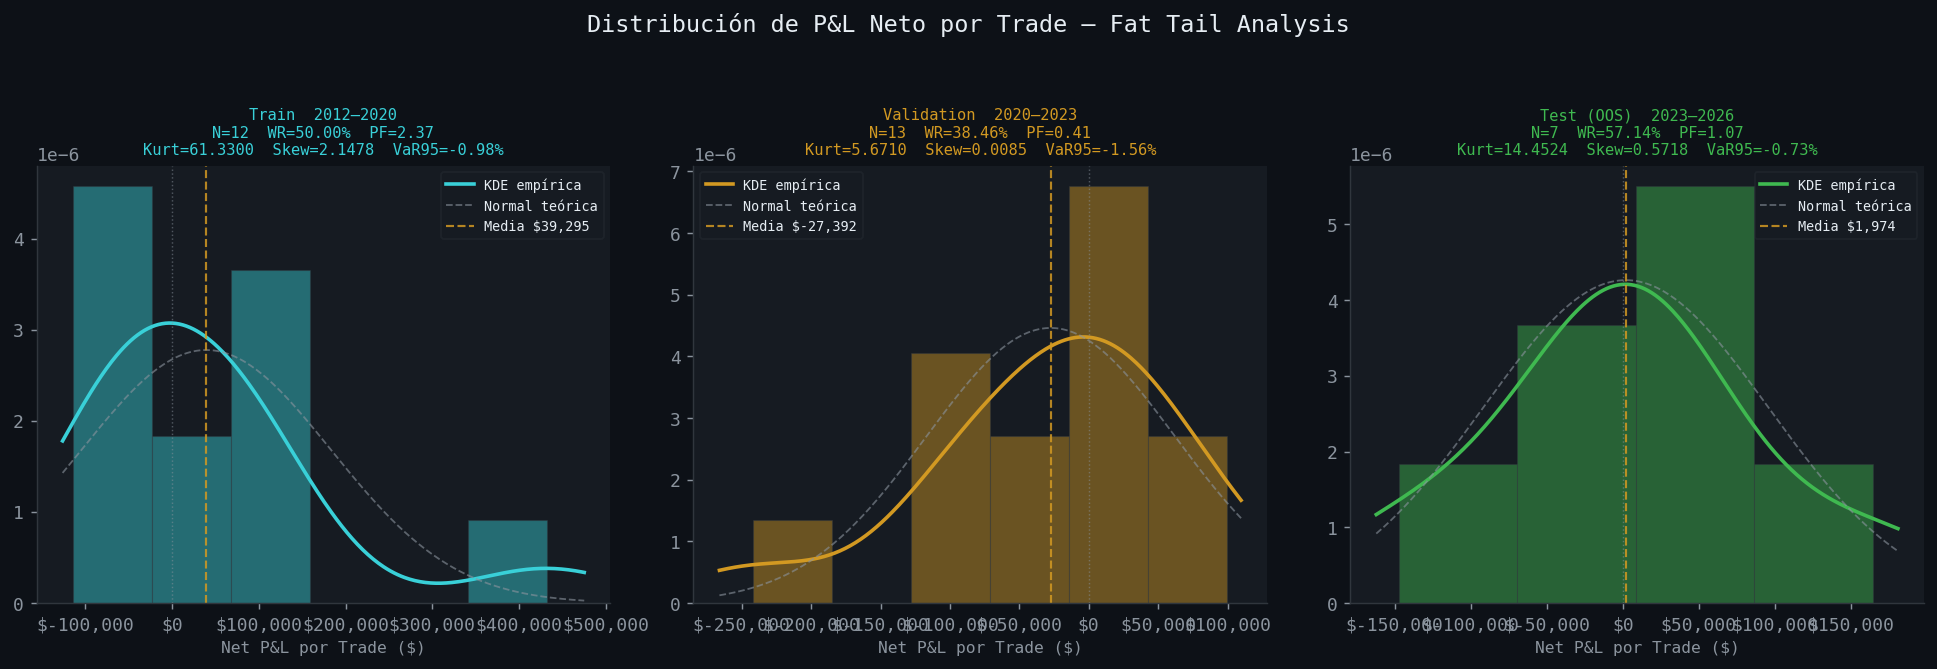

✓ return_distribution.png guardada


In [27]:
from scipy.stats import gaussian_kde, norm

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.patch.set_facecolor(DARK_BG)
fig.suptitle("Distribución de P&L Neto por Trade — Fat Tail Analysis",
             color=TEXT_PRI, fontsize=13, y=1.02)

split_keys   = ["train", "val", "test"]
split_names  = ["Train  2012–2020", "Validation  2020–2023", "Test (OOS)  2023–2026"]
split_colors = [CYAN, AMBER, GREEN]

for ax, sk, sname, sc in zip(axes, split_keys, split_names, split_colors):
    analyst = results[sk]["analyst"]
    dist    = analyst.return_distribution()
    pnl     = dist["per_trade"].dropna()
    ts      = analyst.trade_stats()

    if pnl.empty or len(pnl) < 2:
        ax.set_title(f"{sname}\n(sin trades suficientes)", color=TEXT_SEC, fontsize=9)
        ax.set_facecolor(PANEL_BG)
        continue

    n_bins = max(min(len(pnl) // 2, 20), 4)
    ax.hist(pnl, bins=n_bins, color=sc, alpha=0.45,
            edgecolor=BORDER, linewidth=0.6, density=True)

    x = np.linspace(pnl.min() * 1.1, pnl.max() * 1.1, 300)
    if len(pnl) > 3:
        try:
            kde = gaussian_kde(pnl, bw_method="scott")
            ax.plot(x, kde(x), color=sc, lw=2.0, label="KDE empírica")
        except Exception:
            pass
    ax.plot(x, norm.pdf(x, pnl.mean(), pnl.std()),
            color=TEXT_SEC, lw=1.0, ls="--", alpha=0.6, label="Normal teórica")

    ax.axvline(0,          color=TEXT_SEC, lw=0.8, ls=":", alpha=0.5)
    ax.axvline(pnl.mean(), color=AMBER,    lw=1.2, ls="--", alpha=0.85,
               label=f"Media ${pnl.mean():,.0f}")

    n_tr  = ts.get("n_trades", 0)
    wr    = ts.get("win_rate", float("nan"))
    pf    = ts.get("profit_factor", float("nan"))
    kurt  = dist["daily_kurtosis"]
    skew  = dist["daily_skew"]
    var95 = dist["var_95_pct"]

    def _fmt(v, fmt=".2f"):
        try:    return f"{float(v):{fmt}}"
        except: return "—"

    ax.set_title(
        f"{sname}\n"
        f"N={n_tr}  WR={_fmt(wr*100 if wr==wr else float('nan'))}%  PF={_fmt(pf)}\n"
        f"Kurt={_fmt(kurt,'.4f')}  Skew={_fmt(skew,'.4f')}  VaR95={_fmt(var95)}%",
        color=sc, fontsize=8.5, pad=6
    )
    ax.set_xlabel("Net P&L por Trade ($)", color=TEXT_SEC, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(fontsize=7.5, framealpha=0.3,
              labelcolor=TEXT_PRI, facecolor=PANEL_BG, edgecolor=BORDER)
    ax.set_facecolor(PANEL_BG)

plt.tight_layout()
plt.savefig("return_distribution.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("✓ return_distribution.png guardada")

### 4.7 Resumen Ejecutivo

Impresión final de las métricas clave comparando Train / Val / Test.
Si el Train Sharpe es negativo, se activa el **diagnóstico automático** con sugerencias
técnicas específicas — las únicas métricas que importan al evaluar la estrategia.

In [28]:
BANNER = "═" * 62
print(f"\n{BANNER}")
print("  SPRINT 5 — RESULTADO FINAL  |  Group: JPM / BAC / C")
print(BANNER)

for sk, sname in [("train","TRAIN"), ("val","VAL"), ("test","TEST (OOS)")]:
    cm   = _cm(sk)
    cs   = bt[sk]["cost_summary"]
    tlog = bt[sk]["trade_log"]

    sh   = cm["sharpe_ratio"]
    mdd  = cm["max_drawdown"]
    n_t  = cm["n_trades"]
    cgr  = cm["cost_gross_ratio"]

    # FIX: compute avg_duration outside the f-string to avoid nested quotes
    if not tlog.empty and "duration_days" in tlog.columns:
        avg_dur_val = tlog["duration_days"].mean()
        avg_dur_str = f"{avg_dur_val:.1f}"
    else:
        avg_dur_str = "N/A"

    sh_str  = f"{sh:.4f}"  if sh  == sh  else "NaN"
    cgr_str = f"{cgr:.4f}" if cgr == cgr else "NaN"
    status  = "✓" if sh == sh and sh > 0 else "⚠️"
    flag    = "OK ✓" if cgr == cgr and cgr <= 0.30 else "ALTO ⚠️"

    print(f"\n  {status} {sname}")
    print(f"    Sharpe ratio      : {sh_str}")
    print(f"    Max Drawdown      : {mdd:.2%}")
    print(f"    N Trades          : {n_t}")
    print(f"    Cost/Gross ratio  : {cgr_str}  {flag}")
    print(f"    Net P&L ($)       : {cs['total_net_pnl']:,.2f}")
    print(f"    Avg Duration      : {avg_dur_str} días")

    n_ze = cm.get("n_z_exits",    0)
    n_ts = cm.get("n_time_stops", 0)
    n_zs = cm.get("n_z_stops",    0)
    if n_t > 0:
        print(f"    Exit breakdown    : "
              f"z-exit={n_ze}  time-stop={n_ts}  z-stop={n_zs}")

print(f"\n{BANNER}")

# ── Diagnóstico automático si Sharpe Train negativo ───────────────────────
sh_tr  = _cm("train")["sharpe_ratio"]
cgr_tr = _cm("train")["cost_gross_ratio"]
n_ts_tr = _cm("train").get("n_time_stops", 0)
n_zs_tr = _cm("train").get("n_z_stops",   0)

if sh_tr != sh_tr or sh_tr < 0:
    print("\n  Diagnóstico automático Train:")
    if cgr_tr == cgr_tr and cgr_tr > 0.30:
        print(f"    → Cost/Gross = {cgr_tr:.0%}: comisiones excesivas.")
        print("      Sube z_entry o reduce frecuencia de trades.")
    if n_ts_tr > n_zs_tr:
        print(f"    → {n_ts_tr} time-stops ({TIME_STOP_DAYS}d): spread no revierte.")
        print("      El spread puede tener drift. Considera otro grupo.")
    if n_zs_tr > 0:
        print(f"    → {n_zs_tr} z-stops: spread divergiendo tras entrada.")
        print(f"      ZSCORE_HARD_STOP={ZSCORE_HARD_STOP} funcionó como circuit-breaker.")
    print("\n  Próximos pasos:")
    print("    1. Revisar gráfico de exit types (celda 34)")
    print("    2. Ajustar beta_smoothing_window si hay spikes de z-score")
    print("    3. Probar otro grupo del pipeline_summary")



══════════════════════════════════════════════════════════════
  SPRINT 5 — RESULTADO FINAL  |  Group: JPM / BAC / C
══════════════════════════════════════════════════════════════

  ✓ TRAIN
    Sharpe ratio      : 1.3798
    Max Drawdown      : 13.24%
    N Trades          : 19
    Cost/Gross ratio  : 0.0972  OK ✓
    Net P&L ($)       : 516,060.39
    Avg Duration      : 17.7 días
    Exit breakdown    : z-exit=5  time-stop=4  z-stop=10

  ⚠️ VAL
    Sharpe ratio      : -1.1651
    Max Drawdown      : 14.27%
    N Trades          : 10
    Cost/Gross ratio  : 0.2254  OK ✓
    Net P&L ($)       : -187,186.11
    Avg Duration      : 13.8 días
    Exit breakdown    : z-exit=3  time-stop=1  z-stop=6

  ⚠️ TEST (OOS)
    Sharpe ratio      : -1.6895
    Max Drawdown      : 6.93%
    N Trades          : 1
    Cost/Gross ratio  : 0.0933  OK ✓
    Net P&L ($)       : -45,741.77
    Avg Duration      : 32.0 días
    Exit breakdown    : z-exit=1  time-stop=0  z-stop=0

═════════════════════════